1.	Carga los datos en dos DataFrames distintos.

In [ ]:
import pandas as pd

df1 = pd.read_csv("./docsEJ/temperaturas.csv")
df2 = pd.read_csv("docsEJ/paises.csv")

2.	Muestra las primeras filas de cada DataFrame para entender la estructura de los datos.

In [8]:


print(df2.head())

print(df1.head())

   idpais cca2 cca3    nombre  capital  region         subregion  miembroONU  \
0    1909   MC  MCO    Monaco   Monaco  Europe    Western Europe           1   
1    1910   CY  CYP    Cyprus  Nicosia  Europe   Southern Europe           1   
2    1911   IE  IRL   Ireland   Dublin  Europe   Northern Europe           1   
3    1912   BG  BGR  Bulgaria    Sofia  Europe  Southeast Europe           1   
4    1913   UA  UKR   Ukraine     Kyiv  Europe    Eastern Europe           1   

   capitalLatitud  capitalLongitud  
0           43.73             7.42  
1           35.17            33.37  
2           53.32            -6.23  
3           42.68            23.32  
4           50.43            30.52  
   idtemperaturas  idpais            timestamp  temperatura  sensacion  \
0            2877    1909  2023-12-01 07:30:00         5.77       6.81   
1            2878    1909  2023-12-02 07:30:00        14.27      15.18   
2            2879    1909  2023-12-03 07:30:00        11.69      11.99   
3

3.	Combina las dos tablas utilizando la columna 'idpais' como clave.

In [11]:
df_combinado = pd.merge(df1,df2,on="idpais", how="inner")

df_combinado.head()

,idtemperaturas,idpais,timestamp,temperatura,sensacion,minima,maxima,humedad,amanecer,atardecer,cca2,cca3,nombre,capital,region,subregion,miembroONU,capitalLatitud,capitalLongitud
0,2877,1909,2023-12-01 07:30:00,5.77,6.81,4.67,6.37,85,06:48:37,15:49:40,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
1,2878,1909,2023-12-02 07:30:00,14.27,15.18,13.57,17.15,94,06:49:00,15:52:16,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
2,2879,1909,2023-12-03 07:30:00,11.69,11.99,9.69,13.28,85,06:49:53,15:49:35,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
3,2880,1909,2023-12-04 07:30:00,10.88,9.51,9.46,13.18,85,06:50:35,15:51:02,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
4,2881,1909,2023-12-05 07:30:00,12.67,12.89,11.57,14.41,82,06:47:23,15:53:29,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42


4.	Filtra los datos para mostrar solo los países de Europa. Para ello obtén primero los valores de la variable categórica necesaria.

In [31]:
df_combinado["region"] == "Europe"
df_combinado.head()


,idtemperaturas,idpais,timestamp,temperatura,sensacion,minima,maxima,humedad,amanecer,atardecer,cca2,cca3,nombre,capital,region,subregion,miembroONU,capitalLatitud,capitalLongitud
0,2877,1909,2023-12-01 07:30:00,5.77,6.81,4.67,6.37,85,06:48:37,15:49:40,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
1,2878,1909,2023-12-02 07:30:00,14.27,15.18,13.57,17.15,94,06:49:00,15:52:16,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
2,2879,1909,2023-12-03 07:30:00,11.69,11.99,9.69,13.28,85,06:49:53,15:49:35,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
3,2880,1909,2023-12-04 07:30:00,10.88,9.51,9.46,13.18,85,06:50:35,15:51:02,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42
4,2881,1909,2023-12-05 07:30:00,12.67,12.89,11.57,14.41,82,06:47:23,15:53:29,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42


5.	Calcula la temperatura media para cada país y muestra los resultados.

In [68]:

temperatura_media = df_combinado.groupby("nombre")["temperatura"].mean()
temperatura_media


nombre
Albania                   10.374
Andorra                    9.845
Austria                   10.380
Belarus                    9.332
Belgium                    9.475
Bosnia and Herzegovina     9.476
Bulgaria                  10.928
Croatia                    9.679
Cyprus                     9.124
Czechia                    9.960
Denmark                    8.914
Estonia                   11.174
Faroe Islands              9.959
Finland                    9.570
France                     9.365
Germany                   10.324
Gibraltar                 10.131
Greece                     8.906
Guernsey                   8.726
Hungary                   10.985
Iceland                   11.203
Ireland                   10.144
Isle of Man               12.288
Italy                     10.751
Jersey                    11.662
Kosovo                     9.741
Latvia                     9.013
Liechtenstein              8.805
Lithuania                 10.091
Luxembourg                10.264
Mal

6.	Crea un gráfico de barras mostrando la temperatura media de los países en Europa.

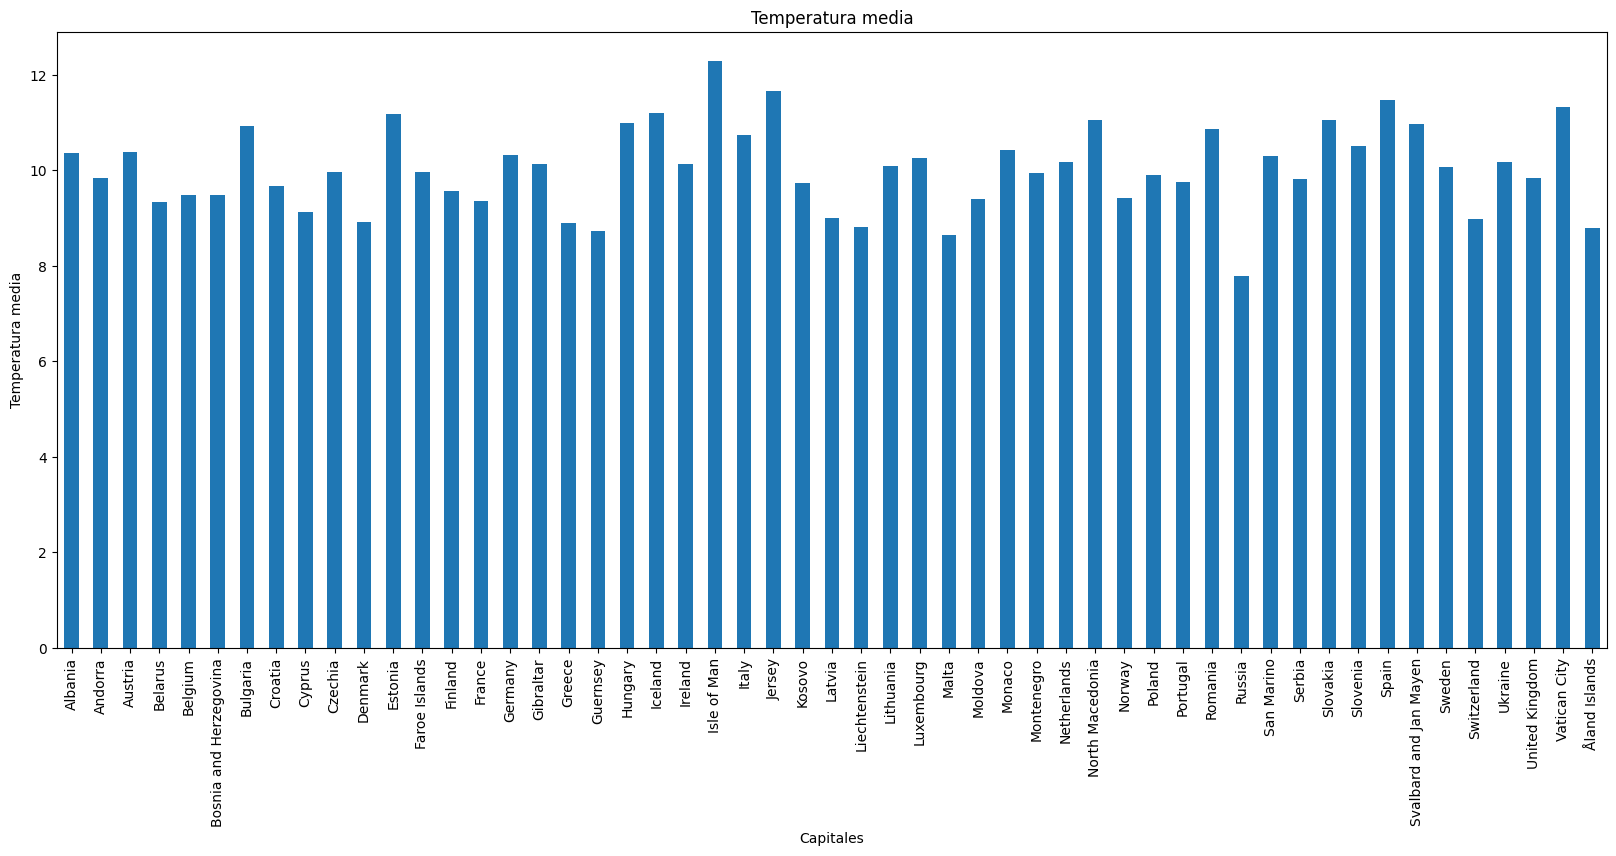

In [69]:
import matplotlib.pyplot as plt

df_europa = df_combinado[df_combinado["region"] == "Europe"]

temp_media = df_europa.groupby("nombre")["temperatura"].mean()

plt.figure(figsize=(20,8))
temp_media.plot(kind="bar")
plt.title("Temperatura media")
plt.xlabel("Capitales")
plt.ylabel("Temperatura media")
plt.xticks(rotation=90)
plt.show()


7.	Encuentra el país con la temperatura media más alta y baja.

In [70]:
temp_media = df_europa.groupby("nombre")["temperatura"].mean()

temp_media_asc = temp_media.sort_values(ascending=True)
print(temp_media_asc.head(1))

temp_media_desc = temp_media.sort_values(ascending=False)
print(temp_media_desc.head(1))




nombre
Russia    7.785
Name: temperatura, dtype: float64
nombre
Isle of Man    12.288
Name: temperatura, dtype: float64


8.	Calcula el promedio de temperatura máxima y mínima en Europa.

In [ ]:

promedio_max = df_europa["maxima"].mean()


promedio_min = df_europa["minima"].mean()

print("maximo:",promedio_max)
print("minimo:",promedio_min)


maximo: 11.78733962264151
minimo: 8.266452830188678


9.	Visualiza la evolución temporal de la temperatura para un país específico.

C:\Users\ROG STRIX\AppData\Local\Temp\ipykernel_28296\2983754554.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pais["timestamp"] = pd.to_datetime(df_pais["timestamp"])


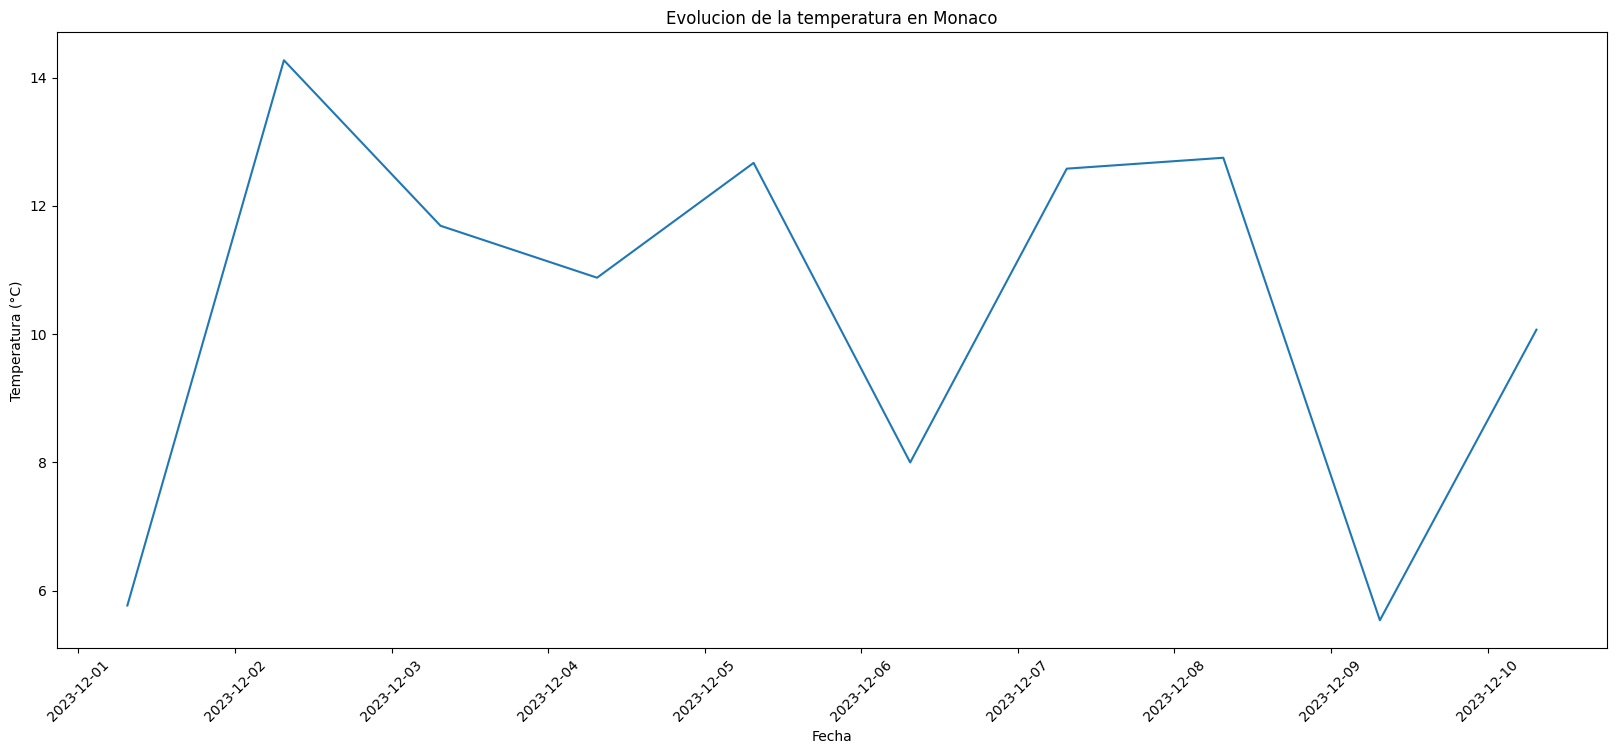

In [91]:
import matplotlib.pyplot as plt


pais_especifico = input("Dime qué país quieres ver: ")


df_europa = df_combinado[df_combinado["region"] == "Europe"]

df_pais = df_europa[df_europa["nombre"] == pais_especifico]


df_pais["timestamp"] = pd.to_datetime(df_pais["timestamp"])


df_pais = df_pais.sort_values("timestamp")

plt.figure(figsize=(20,8))
plt.plot(df_pais["timestamp"], df_pais["temperatura"], linestyle='-')
plt.title(f"Evolucion de la temperatura en {pais_especifico}")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.show()
